# Introduction à Stable Diffusion

Ce *notebook* va couvrir les bases de l'utilisation de Stable Diffusion pour créer et modifier des images en utilisant les pipelines existants. Nous allons également jeter un bref coup d'œil aux composants clés au sein du pipeline, tout en laissant une exploration plus approfondie de ces derniers au *notebook* de plongée profonde. Plus précisément, nous aborderons les points suivants :

- Générer des images à partir d'un texte en utilisant le `StableDiffusionPipeline` et en expérimentant avec les arguments disponibles
- Voir certains des composants clés du pipeline en action
	- Le VAE qui en fait un "modèle de diffusion latent".
	- Le *tokenizer* et l'encodeur qui traitent le prompt textuel
	- L'UNet lui-même
    - Le planificateur et l'exploration de différents planificateurs
- Reproduction de la boucle d'échantillonnage avec les composants du pipeline
- Édition d'images existantes avec le pipeline Img2Img
- Utilisation des pipelines inpainting et Depth2Img

❓ Si vous avez des questions, merci de les poster sur le canal `#diffusion-models-class` du [serveur Discord d'Hugging Face](https://huggingface.co/join/discord).


# Configuration

In [ ]:
!pip install -Uq diffusers ftfy accelerate

In [ ]:
# Installer transformers à partir de la source car nous avons besoin de la dernière version pour Depth2Img
!pip install -Uq git+https://github.com/huggingface/transformers 

In [ ]:
import torch
import requests
from PIL import Image
from io import BytesIO
from matplotlib import pyplot as plt

# Nous allons explorer un certain nombre de pipelines aujourd'hui !
from diffusers import (
    StableDiffusionPipeline, 
    StableDiffusionImg2ImgPipeline,
    StableDiffusionInpaintPipeline, 
    StableDiffusionDepth2ImgPipeline
    )       

# Nous utiliserons quelques images de démonstration plus loin dans le notebook
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Télécharger des images pour l'exemple d'inpainting
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = download_image(img_url).resize((512, 512))
mask_image = download_image(mask_url).resize((512, 512))

In [ ]:
# Définir l'appareil
device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# Générer des images à partir d'un texte

Chargeons un pipeline Stable Diffusion et voyons ce qu'il peut faire. Il existe plusieurs versions de Stable Diffusion, la plus récente étant la version 2.1. Si vous souhaitez explorer une version plus ancienne, remplacez simplement l'ID du modèle par le modèle approprié (par exemple, vous pouvez essayer "CompVis/stable-diffusion-v1-4" ou choisir un modèle à partir de la [bibliothèque de concepts dreambooth](https://huggingface.co/sd-dreambooth-library)).

In [ ]:
# Charger le pipeline
model_id = "stabilityai/stable-diffusion-2-1-base"
pipe = StableDiffusionPipeline.from_pretrained(model_id).to(device)

Si vous manquez de mémoire GPU, vous pouvez faire certaines choses pour réduire l'utilisation de la RAM :
- Chargez la version FP16 (non supportée par tous les systèmes). Avec cette version, vous devrez peut-être convertir les tenseurs en torch.float16 lorsque vous expérimenterez avec les composants individuels du pipeline :
```
pipe = StableDiffusionPipeline.from_pretrained(model_id, revision="fp16", torch_dtype=torch.float16).to(device)
```
- Activer le découpage de l'attention. Cela permet de réduire l'utilisation de la mémoire du GPU au prix d'une légère réduction de la vitesse :
```
pipe.enable_attention_slicing()
```
- Réduire la taille des images générées

Une fois le pipeline chargé, nous pouvons générer une image sur la base d'un prompt avec le code suivant :

  0%|          | 0/35 [00:00<?, ?it/s]

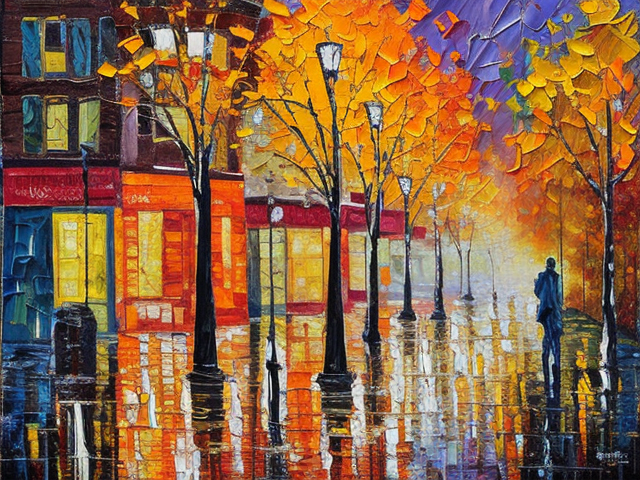

In [ ]:
# Mise en place d'un générateur pour la reproductibilité
generator = torch.Generator(device=device).manual_seed(42)

# Exécuter le pipeline, en montrant certains des arguments disponibles
pipe_output = pipe(
    prompt="Palette knife painting of an autumn cityscape", # Ce qu'il faut générer
    negative_prompt="Oversaturated, blurry, low quality", # Ce qu'il ne faut PAS générer
    height=480, width=640,     # Spécifier la taille de l'image
    guidance_scale=8,          # Comment suivre avec fermeté le prompt
    num_inference_steps=35,    # Nombre d'étapes
    generator=generator        # Graine aléatoire fixe
)

# Visualiser l'image obtenue :
pipe_output.images[0]

**Exercice** : Passez un peu de temps à jouer avec la cellule ci-dessus en utilisant vos propres prompts et en modifiant les paramètres pour voir comment ils affectent la sortie. Utilisez une graine aléatoire différente ou supprimez l'argument du `generator` pour obtenir des résultats différents à chaque fois.

Arguments clés à modifier :
- La largeur et la hauteur spécifient la taille de l'image générée. Elles doivent être divisibles par 8 pour que le VAE fonctionne (ce que nous verrons dans une prochaine section).
- Le nombre de pas influence la qualité de la génération. La valeur par défaut (50) fonctionne bien, mais dans certains cas, on peut se contenter de 20 pas, ce qui est pratique pour l'expérimentation.
- Le prompt négatif est utilisé pendant le processus d'orientation sans classifieur et peut être un moyen utile d'ajouter un contrôle supplémentaire. Vous pouvez ne pas l'utiliser, mais de nombreux utilisateurs trouvent utile de lister certaines descriptions indésirables dans le prompt négatif, comme illustré ci-dessus.
- L'argument guidance_scale détermine l'intensité du guidage sans classifieur (CFG pour *classifier-free guidance*). Des échelles plus élevées poussent les images générées à mieux correspondre au prompt, mais si l'échelle est trop élevée, les résultats peuvent devenir sursaturés et désagréables.

Si vous souhaitez vous inspirer d'un prompt, le [Stable Diffusion Prompt Book](https://app.usp.ai/static/Stable%20Diffusion%202.1%20Prompt%20Book%20by%20USP.ai.pdf) est un bon point de départ.

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

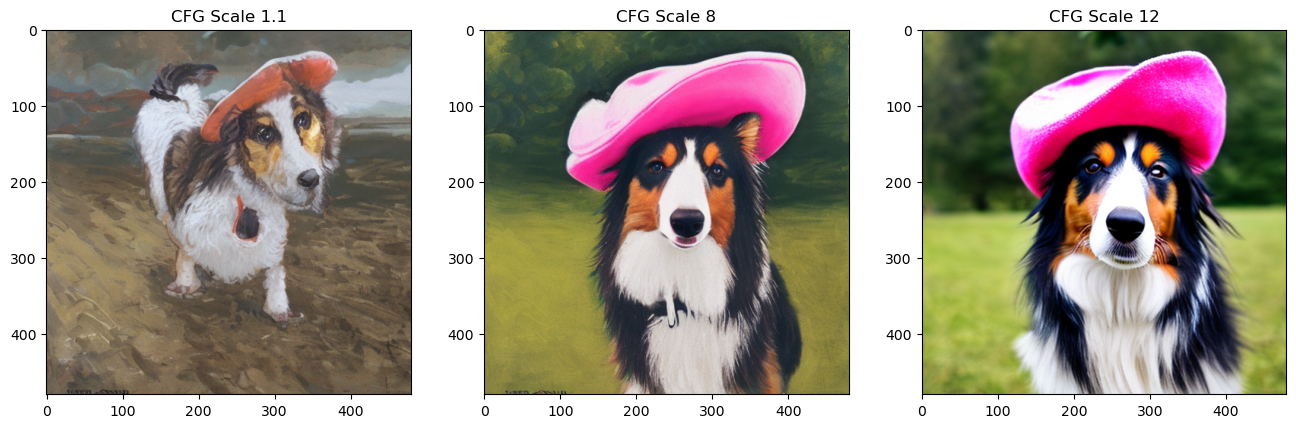

In [ ]:
cfg_scales = [1.1, 8, 12] #@param
prompt = "A collie with a pink hat" #@param
fig, axs = plt.subplots(1, len(cfg_scales), figsize=(16, 5))
for i, ax in enumerate(axs):
  im = pipe(prompt, height=480, width=480,
    guidance_scale=cfg_scales[i], num_inference_steps=35,
    generator=torch.Generator(device=device).manual_seed(42)).images[0]
  ax.imshow(im); ax.set_title(f'CFG Scale {cfg_scales[i]}');

Modifiez les valeurs ci-dessus pour essayer différentes échelles et différents prompts. L'interprétation est bien sûr subjective, mais par expérience, toute valeur comprise entre 8 et 12 donne de meilleurs résultats que les valeurs inférieures ou supérieures à cette fourchette.

# Composants du pipeline

Le `StableDiffusionPipeline` que nous utilisons est un peu plus complexe que le `DDPMPipeline` que nous avons exploré dans les unités précédentes. En plus du UNet et du planificateur, il y a un certain nombre d'autres composants inclus dans le pipeline :

In [ ]:
print(list(pipe.components.keys())) # Liste des composants

['vae', 'text_encoder', 'tokenizer', 'unet', 'scheduler', 'safety_checker', 'feature_extractor']


Pour mieux comprendre le fonctionnement du pipeline, voyons brièvement chaque composant en action individuellement, puis assemblons-les pour reproduire la fonctionnalité du pipeline.

### Le VAE

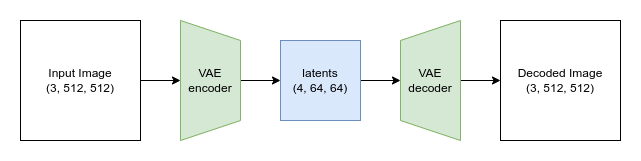

Le VAE (auto-encodeur variationnel) est un type de modèle capable d'encoder son entrée dans une représentation comprimée, puis de décoder cette représentation latente pour la rendre proche de l'entrée d'origine. Lors de la génération d'images avec diffusion stable, nous générons d'abord les latents en appliquant le processus de diffusion dans l'espace latent du VAE, puis nous les décodons à la fin pour visualiser l'image résultante.

Voici un code qui prend une image d'entrée, l'encode dans une représentation latente et la décode à nouveau à l'aide de la VAE :

In [ ]:
# Créez de fausses données (une image aléatoire, une plage (-1, 1))
images = torch.rand(1, 3, 512, 512).to(device) * 2 - 1 
print("Input images shape:", images.shape)

# Encoder dans l'espace latent
with torch.no_grad():
  latents = 0.18215 * pipe.vae.encode(images).latent_dist.mean
print("Encoded latents shape:", latents.shape)

# Décoder à nouveau
with torch.no_grad():
  decoded_images = pipe.vae.decode(latents / 0.18215).sample
print("Decoded images shape:", decoded_images.shape)

Input images shape: torch.Size([1, 3, 512, 512])
Encoded latents shape: torch.Size([1, 4, 64, 64])
Decoded images shape: torch.Size([1, 3, 512, 512])


Comme vous pouvez le constater, l'image 512x512 est compressée en une représentation latente 64x64 (avec quatre canaux). Cette réduction par 8 de chaque dimension spatiale est la raison pour laquelle la largeur et la hauteur spécifiées doivent être des multiples de 8.

Travailler avec ces latents 4x64x64 riches en informations est plus efficace que de travailler avec des images massives de 512 px, ce qui permet d'obtenir des modèles de diffusion plus rapides dont l'entraînement et l'utilisation nécessitent moins de ressources. Le processus de décodage du VAE n'est pas parfait, mais il est suffisamment bon pour que le petit compromis de qualité en vaille généralement la peine.

NB : L'exemple de code ci-dessus inclut un facteur d'échelle de 0,18215 nécessaire pour correspondre au traitement utilisé lors de l'entraînement de SD.

### Le *tokenizer* et l'encodeur

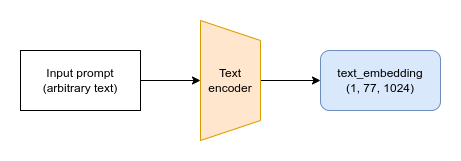

L'objectif de l'encodeur est de transformer une chaîne d'entrée (le prompt) en une représentation numérique qui peut être transmise à l'UNet en tant que conditionnement. Le texte est d'abord transformé en une série de *tokens* à l'aide du *tokenizer* du pipeline. L'encodeur dispose d'un vocabulaire d'environ 50K *tokens* et tout mot ne figurant pas dans ce vocabulaire est divisé en sous-mots plus petits. Les *tokens* sont ensuite transmis à l'encodeur lui-même : un transformer qui a été entraîné à l'origine comme encodeur pour CLIP. Nous espérons que ce transformer pré-entraîné a appris des représentations riches du texte qui seront également utiles pour la tâche de diffusion.

Testons ce processus en encodant un prompt d'exemple, d'abord en le tokenizant manuellement et en le faisant passer par l'encodeur puis en utilisant la méthode `_encode_prompt` pour montrer le processus complet, y compris le rembourrage/la troncature de la longueur jusqu'à la longueur maximale de 77 *tokens* :

In [ ]:
# Tokenizer et encoder un prompt d'exemple manuellement :

# Tokenizer
input_ids = pipe.tokenizer(["A painting of a flooble"])['input_ids']
print("Input ID -> decoded token")
for input_id in input_ids[0]:
  print(f"{input_id} -> {pipe.tokenizer.decode(input_id)}")

# Passage par l'encodeur de texte CLIP
input_ids = torch.tensor(input_ids).to(device)
with torch.no_grad():
  text_embeddings = pipe.text_encoder(input_ids)['last_hidden_state']
print("Text embeddings shape:", text_embeddings.shape)

Input ID -> decoded token
49406 -> <|startoftext|>
320 -> a
3086 -> painting
539 -> of
320 -> a
4062 -> floo
1059 -> ble
49407 -> <|endoftext|>
Text embeddings shape: torch.Size([1, 8, 1024])


In [ ]:
# Obtenir les enchâssements finaux à l'aide de la fonction _encode_prompt du pipeline :
text_embeddings = pipe._encode_prompt("A painting of a flooble", device, 1, False, '')
text_embeddings.shape

torch.Size([1, 77, 1024])

Ces enchâssements (les "états cachés" du dernier bloc de transformation dans le modèle de l'encodeur) seront transmis à l'UNet en tant qu'argument supplémentaire de la méthode `forward`, que nous verrons dans la section suivante.

### L'UNet

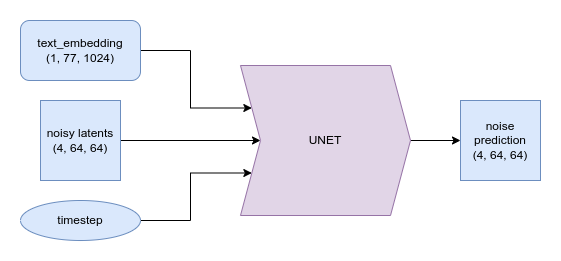

L'UNet prend une entrée bruitée et prédit le bruit, tout comme les UNets que nous avons vus dans les unités précédentes. Contrairement aux exemples précédents, l'entrée n'est pas une image mais une représentation latente d'une image. En plus du conditionnement du pas de temps, ce UNet prend également en compte l'enchâssement du prompt en tant qu'entrée supplémentaire. Ici, il fait des prédictions sur des données fictives :

In [ ]:
# Entrées fictives
timestep = pipe.scheduler.timesteps[0]
latents = torch.randn(1, 4, 64, 64).to(device)
text_embeddings = torch.randn(1, 77, 1024).to(device)

# Prédiction du modèle
with torch.no_grad():
  unet_output = pipe.unet(latents, timestep, text_embeddings).sample
print('UNet output shape:', unet_output.shape) # Same shape as the input latents

UNet output shape: torch.Size([1, 4, 64, 64])


### Le planificateur

Le planificateur stocke le plan de bruit et gère la mise à jour de l'échantillon bruité sur la base des prédictions du modèle. Le planificateur par défaut est un `PNDMScheduler`, mais vous pouvez en utiliser d'autres (comme `LMSDiscreteScheduler`) tant qu'ils sont initialisés avec la même configuration.

Nous pouvons tracer le plan de bruit pour voir le niveau de bruit (basé sur $bar{\alpha}$) au fil du temps :

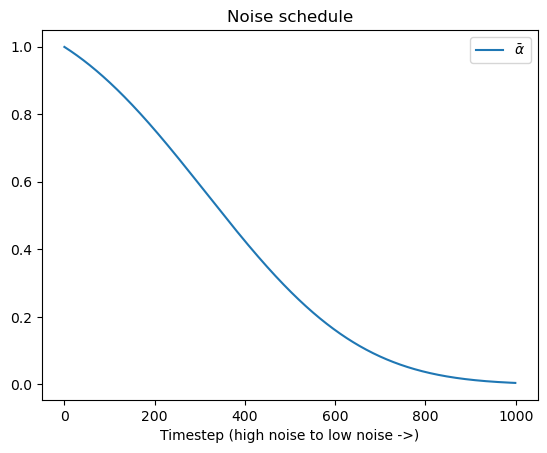

In [ ]:
plt.plot(pipe.scheduler.alphas_cumprod, label=r'$\bar{\alpha}$')
plt.xlabel('Timestep (high noise to low noise ->)');
plt.title('Noise schedule');plt.legend();

Si vous souhaitez essayer un autre planificateur, vous pouvez le remplacer comme suit :

Scheduler config: LMSDiscreteScheduler {
  "_class_name": "LMSDiscreteScheduler",
  "_diffusers_version": "0.11.1",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "clip_sample": false,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "set_alpha_to_one": false,
  "skip_prk_steps": true,
  "steps_offset": 1,
  "trained_betas": null
}



  0%|          | 0/50 [00:00<?, ?it/s]

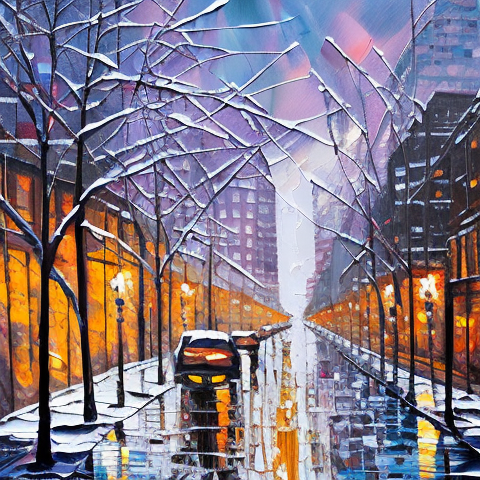

In [ ]:
from diffusers import LMSDiscreteScheduler

# Remplacer le planificateur
pipe.scheduler = LMSDiscreteScheduler.from_config(pipe.scheduler.config)

# Afficher la configuration
print('Scheduler config:', pipe.scheduler)

# Générer une image avec ce nouveau plannificateur
pipe(prompt="Palette knife painting of an winter cityscape", height=480, width=480,
     generator=torch.Generator(device=device).manual_seed(42)).images[0]

Vous pouvez lire plus de détails sur l'utilisation de différents planificateurs [ici](https://huggingface.co/docs/diffusers/v0.17.1/en/api/pipelines/stable_diffusion/overview#how-to-load-and-use-different-schedulers).

### Une boucle d'échantillonnage par vous-même

Maintenant que nous avons vu tous ces composants en action, nous pouvons les assembler pour reproduire la fonctionnalité du pipeline :

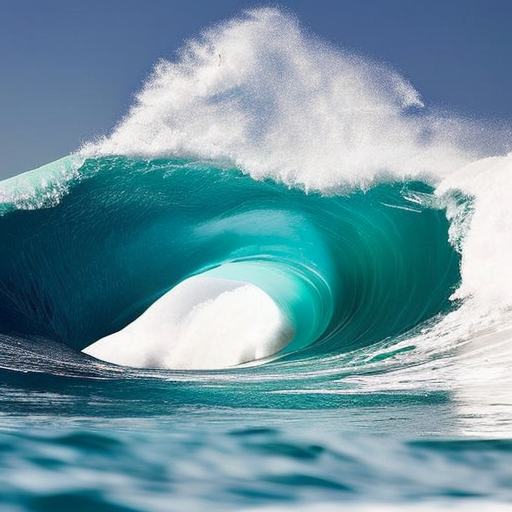

In [ ]:
guidance_scale = 8 #@param
num_inference_steps=30 #@param
prompt = "Beautiful picture of a wave breaking" #@param
negative_prompt = "zoomed in, blurry, oversaturated, warped" #@param

# Encoder le prompt
text_embeddings = pipe._encode_prompt(prompt, device, 1, True, negative_prompt)

# Créer notre point de départ aléatoire
latents = torch.randn((1, 4, 64, 64), device=device, generator=generator)
latents *= pipe.scheduler.init_noise_sigma

# Preparer le planificateur
pipe.scheduler.set_timesteps(num_inference_steps, device=device)

# Boucle sur les pas de temps d'échantillonnage
for i, t in enumerate(pipe.scheduler.timesteps):

  # développer les latents si l'on procède à un guidage sans classifieur
  latent_model_input = torch.cat([latents] * 2)

  # Appliquer tout échelonnement requis par le planificateur
  latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

  # prédire le bruit résiduel avec l'UNet
  with torch.no_grad():
    noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

  # réaliser un guidage
  noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
  noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

  # calculer l'échantillon bruité précédent x_t -> x_t-1
  latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

# Décoder les latents résultants en une image
with torch.no_grad():
  image = pipe.decode_latents(latents.detach())

# Visualiser
pipe.numpy_to_pil(image)[0]

Dans la plupart des cas, il sera plus facile d'utiliser les pipelines existants, mais le fait de disposer de cette boucle d'échantillonnage bidouillable peut s'avérer utile pour comprendre et modifier le fonctionnement de chaque composant. Si vous souhaitez voir ce code et tous les différents composants explorés et modifiés en profondeur, consultez le [*notebook*](https://github.com/fastai/diffusion-nbs/blob/master/Stable%20Diffusion%20Deep%20Dive.ipynb) et la [video](https://m.youtube.com/watch?v=0_BBRNYInx8) 'Stable Diffusion Deep Dive' pour une exploration plus approfondie.

## Pipelines supplémentaires

Que pouvons-nous faire d'autre que de générer des images à partir d'un prompt ? Beaucoup de choses ! Dans cette section, nous allons démontrer quelques pipelines sympas pour vous donner un avant-goût des autres tâches pour lesquelles Stable Diffusion peut être utilisé. Plusieurs d'entre eux nécessitent le téléchargement de nouveaux modèles, donc si vous êtes pressé, vous pouvez parcourir cette section en vous contentant de regarder les résultats existants plutôt que de télécharger et d'exécuter tous les modèles vous-même.

## Img2Img

Dans les exemples présentés jusqu'à présent, nous avons généré des images en partant de latents aléatoires et en appliquant la boucle complète d'échantillonnage par diffusion. Mais il n'est pas nécessaire de partir de zéro. Le pipeline Img2Img encode d'abord une image existante dans un ensemble de latents, puis ajoute du bruit aux latents et utilise cette image comme point de départ. La quantité de bruit ajoutée et le nombre d'étapes de débruitage appliquées déterminent la "force" du processus Img2Img. L'ajout d'une petite quantité de bruit (force faible) n'entraînera que très peu de changements, tandis que l'ajout d'une quantité maximale de bruit et l'exécution du processus de débruitage complet donneront une image qui ne ressemblera guère à l'image d'entrée, hormis quelques similitudes au niveau de la structure générale.

Ce pipeline ne nécessite pas de modèles particuliers, et tant que l'ID du modèle est le même que celui de notre exemple texte-image ci-dessus, aucun nouveau fichier ne devra être téléchargé.

In [ ]:
# Chargement d'un pipeline Img2Img
model_id = "stabilityai/stable-diffusion-2-1-base"
img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(model_id).to(device)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Dans la section Configuration nous avons chargé un exemple `init_image` à utiliser pour cette démo, mais vous pouvez le remplacer par votre propre image si vous préférez. Voici le pipeline en action :

  0%|          | 0/30 [00:00<?, ?it/s]

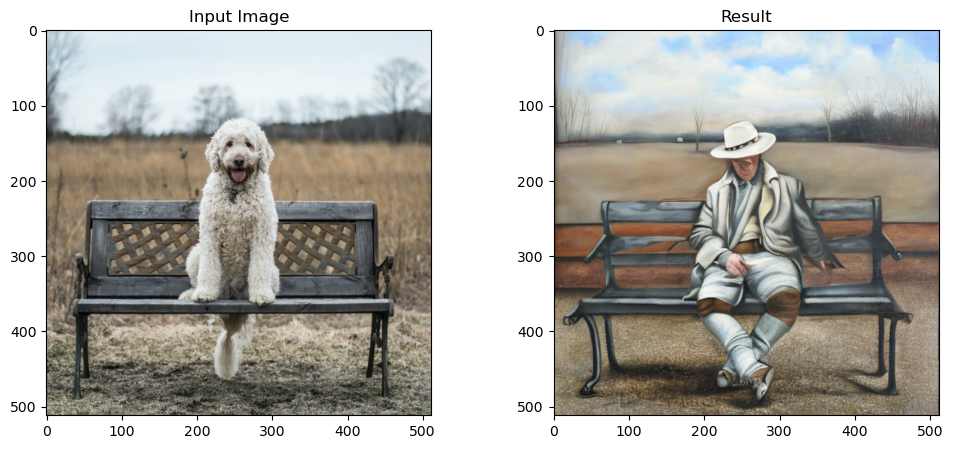

In [ ]:
# Appliquer Img2Img
result_image = img2img_pipe(
    prompt="An oil painting of a man on a bench",
    image = init_image, # L'image de départ
    strength = 0.6, # 0 pour aucun changement, 1.0 pour une force maximale
).images[0]

# Voir le résultat
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(init_image);axs[0].set_title('Input Image')
axs[1].imshow(result_image);axs[1].set_title('Result');

**Exercice** : Expérimentez avec ce pipeline. Essayez vos propres images, ou jouez avec différentes forces et différents prompts. Vous pouvez utiliser les mêmes arguments que pour le pipeline texte-image, alors n'hésitez pas à essayer différentes tailles, différents nombres d'étapes, etc.

## Inpainting

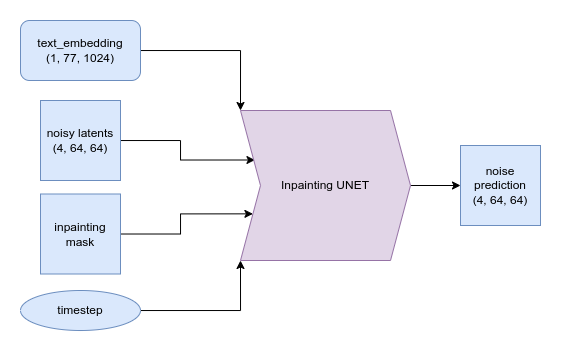

Que se passerait-il si nous voulions conserver une partie de l'image d'entrée inchangée mais générer quelque chose de nouveau dans d'autres parties ? C'est ce qu'on appelle l'*inpainting*. Bien qu'il soit possible de le faire avec le même modèle que les démonstrations précédentes (via `StableDiffusionInpaintPipelineLegacy`), nous pouvons obtenir de meilleurs résultats en utilisant une version *finetunée* personnalisée de Stable Diffusion qui prend un masque comme condition supplémentaire. L'image du masque doit avoir la même forme que l'image d'entrée, avec du blanc dans les zones à remplacer et du noir dans les zones à garder inchangées. Voici comment charger un tel pipeline et l'appliquer à l'image d'exemple et au masque chargés dans la section Configuration :

In [ ]:
# Charger le pipeline d'inpainting (nécessite un modèle d'inpainting approprié)
pipe = StableDiffusionInpaintPipeline.from_pretrained("runwayml/stable-diffusion-inpainting")
pipe = pipe.to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

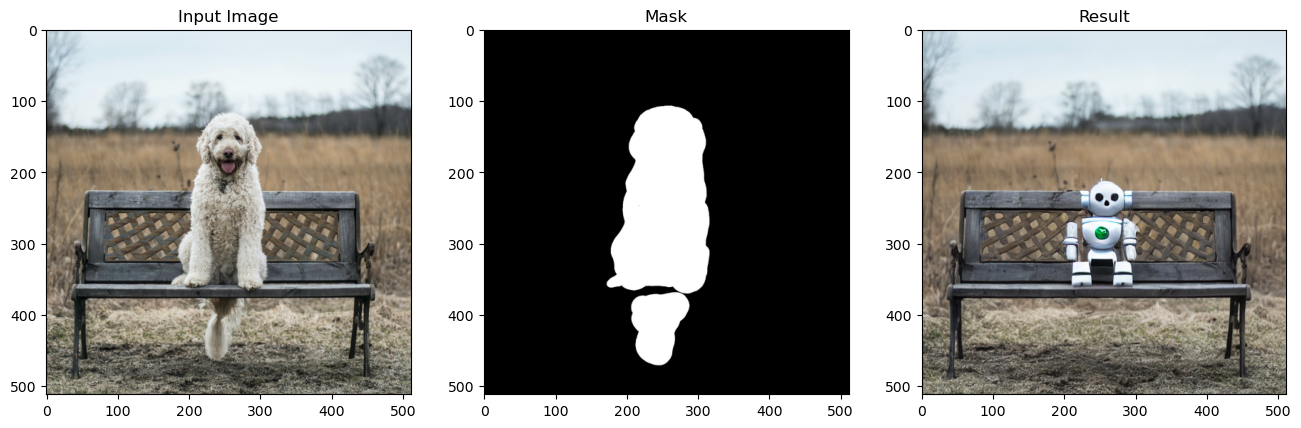

In [ ]:
# Inpaint avec un prompt pour avoir le résultat souhaité
prompt = "A small robot, high resolution, sitting on a park bench"
image = pipe(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

# Voir le résultat
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(init_image);axs[0].set_title('Input Image')
axs[1].imshow(mask_image);axs[1].set_title('Mask')
axs[2].imshow(image);axs[2].set_title('Result');

Ce modèle peut être particulièrement puissant lorsqu'il est combiné à un autre modèle pour générer automatiquement des masques. Par exemple, ce [Space](https://huggingface.co/spaces/nielsr/text-based-inpainting) utilise un modèle appelé CLIPSeg pour masquer un objet à remplacer sur la base d'une description textuelle.

#### En marge : gestion du cache de votre modèle

L'exploration de différents pipelines et variantes de modèles peut remplir votre espace disque. Vous pouvez voir quels modèles sont actuellement téléchargés avec :

In [ ]:
!ls ~/.cache/huggingface/diffusers/ # Liste du contenu du répertoire cache

models--CompVis--stable-diffusion-v1-4
models--ddpm-bedroom-256
models--google--ddpm-bedroom-256
models--google--ddpm-celebahq-256
models--runwayml--stable-diffusion-inpainting
models--stabilityai--stable-diffusion-2-1-base


Consultez la [documentation](https://huggingface.co/docs/huggingface_hub/main/guides/manage-cache) sur la mise en cache pour savoir comment visualiser et gérer efficacement votre cache.

## Depth2Image


Img2Img est très bien, mais parfois nous voulons créer une nouvelle image avec la composition de l'original mais avec des couleurs ou des textures complètement différentes. Il peut être difficile de trouver une force d'Img2Img qui préserve ce que nous voulons de la mise en page sans conserver les couleurs d'entrée.

Il est temps d'adopter un autre modèle *finetuné* ! Celui-ci prend en compte les informations de profondeur comme condition supplémentaire lors de la génération. Le pipeline utilise un modèle d'estimation de la profondeur pour créer une carte de profondeur, qui est ensuite transmise au UNet *finetuné* lors de la génération d'images afin de préserver (si possible) la profondeur et la structure de l'image initiale tout en remplissant un contenu complètement nouveau.

In [ ]:
# Charger le pipeline Depth2Img (nécessite un modèle approprié)
pipe = StableDiffusionDepth2ImgPipeline.from_pretrained("stabilityai/stable-diffusion-2-depth")
pipe = pipe.to(device)

  0%|          | 0/40 [00:00<?, ?it/s]

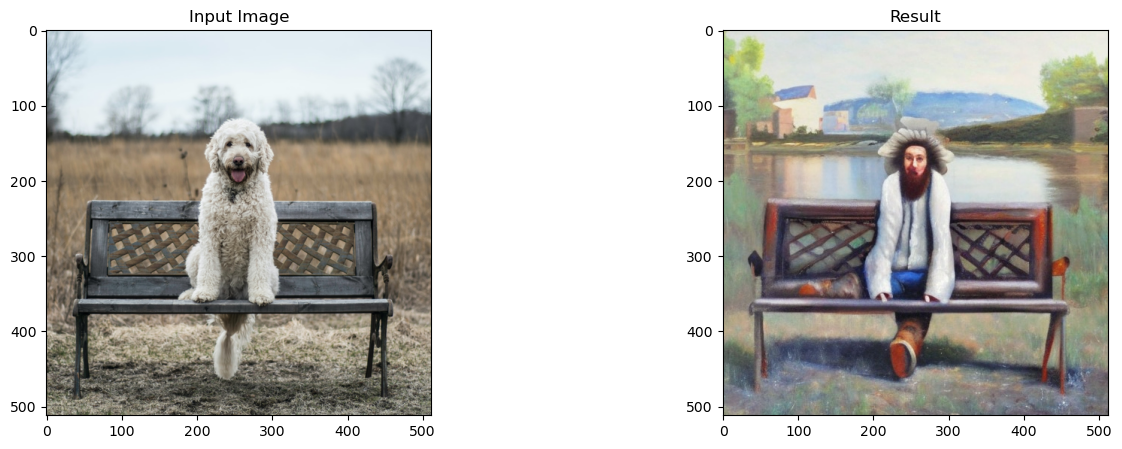

In [ ]:
# Inpaint avec un prompt pour avoir le résultat souhaité
prompt = "An oil painting of a man on a bench"
image = pipe(prompt=prompt, image=init_image).images[0]

# Voir le résultat
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].imshow(init_image);axs[0].set_title('Input Image')
axs[1].imshow(image);axs[1].set_title('Result');

Notez la comparaison avec l'exemple img2img. Ici, la variation de couleur est beaucoup plus importante mais la structure globale reste fidèle à l'original. Ce n'est pas idéal dans ce cas, car l'homme a été doté d'une anatomie extrêmement bizarre pour correspondre à la forme du chien, mais dans certains cas, c'est extraordinairement utile. Pour un exemple  de cette approche, regardez ce [tweet](https://twitter.com/CarsonKatri/status/1600248599254007810?s=20&t=BlzSK26sfqi2336SN0gKpQ) montrant le modèle de profondeur utilisé pour texturer une scène en 3D !

# Et maintenant ?

Nous espérons vous avoir donné un avant-goût des nombreuses possibilités offertes par Stable Diffusion ! Une fois que vous en aurez assez de jouer avec les exemples de ce *notebook*, allez voir le *notebook* du hackathon DreamBooth pour voir comment *finetuner* votre propre version de Stable Diffusion qui peut être utilisée avec les pipelines texte-image ou img2img que nous avons vus ici.

Si vous êtes curieux d'approfondir le fonctionnement des différents composants, consultez le *notebook* Stable Diffusion Deep Dive qui va beaucoup plus loin dans les détails et montre quelques astuces supplémentaires que nous pouvons faire.

N'oubliez pas de partager vos créations avec nous et la communauté !